In [28]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("diabetes_risk_prediction_dataset.csv")
ff = pd.read_csv("diabetes_risk_prediction_dataset.csv")
df.head(3)

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High


In [29]:
df = df.drop(columns=["Patient_ID","AI_Health_Recommendation"])
df.head(1)

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,Doctor_Consultation_Needed,Diabetes_Risk
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Yes,Yes,No,Good,Retired,Rural,4.4,60,Yes,Moderate


In [30]:
print(list(df.columns),sep="--")

['Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score', 'Doctor_Consultation_Needed', 'Diabetes_Risk']


In [31]:
y = df['Diabetes_Risk']

In [81]:
df.isnull().sum()

Age                           0
Gender                        0
Country                       0
Height_cm                     0
Weight_kg                     0
BMI                           0
Waist_Circumference_cm        0
Blood_Glucose                 0
HbA1c                         0
Fasting_Blood_Sugar           0
Insulin_Level                 0
Blood_Pressure_Systolic       0
Blood_Pressure_Diastolic      0
Total_Cholesterol             0
HDL                           0
LDL                           0
Triglycerides                 0
Heart_Rate                    0
Physical_Activity_Level       0
Exercise_Hours_Per_Week       0
Daily_Walking_Minutes         0
Diet_Quality                  0
Sugar_Intake_Level            0
Sleep_Hours                   0
Stress_Level                  0
Smoking_Status                0
Alcohol_Consumption           0
Family_History_Diabetes       0
Hypertension                  0
Heart_Disease                 0
Fatty_Liver                   0
PCOS    

In [33]:
# Numeric columns ko median ya mean se bharein
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# Categorical (text) columns ko mode (most frequent) se bharein
cat_cols = df.select_dtypes(include=['str','object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

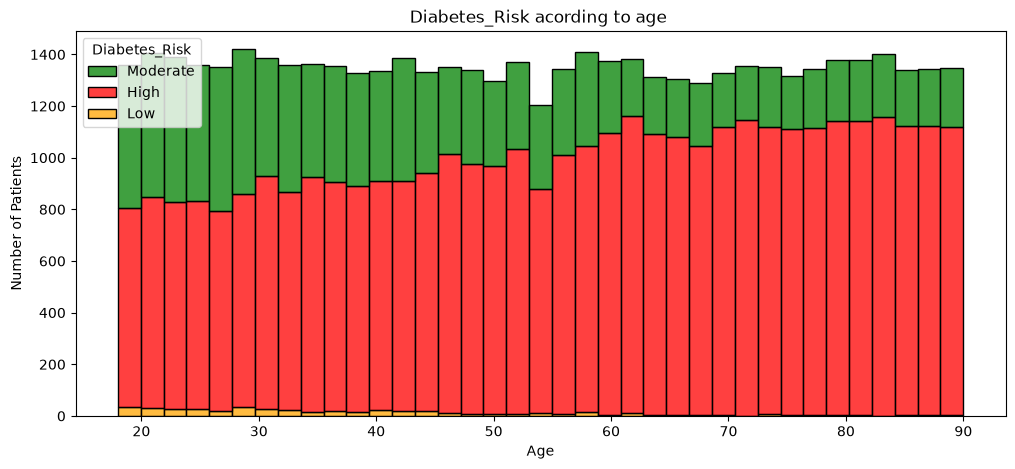

In [34]:
plt.figure(figsize=(12,5))
sns.histplot(data= df, hue= 'Diabetes_Risk',x = 'Age',palette= ['green','red','orange'],multiple= 'stack')
plt.title("Diabetes_Risk acording to age ")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

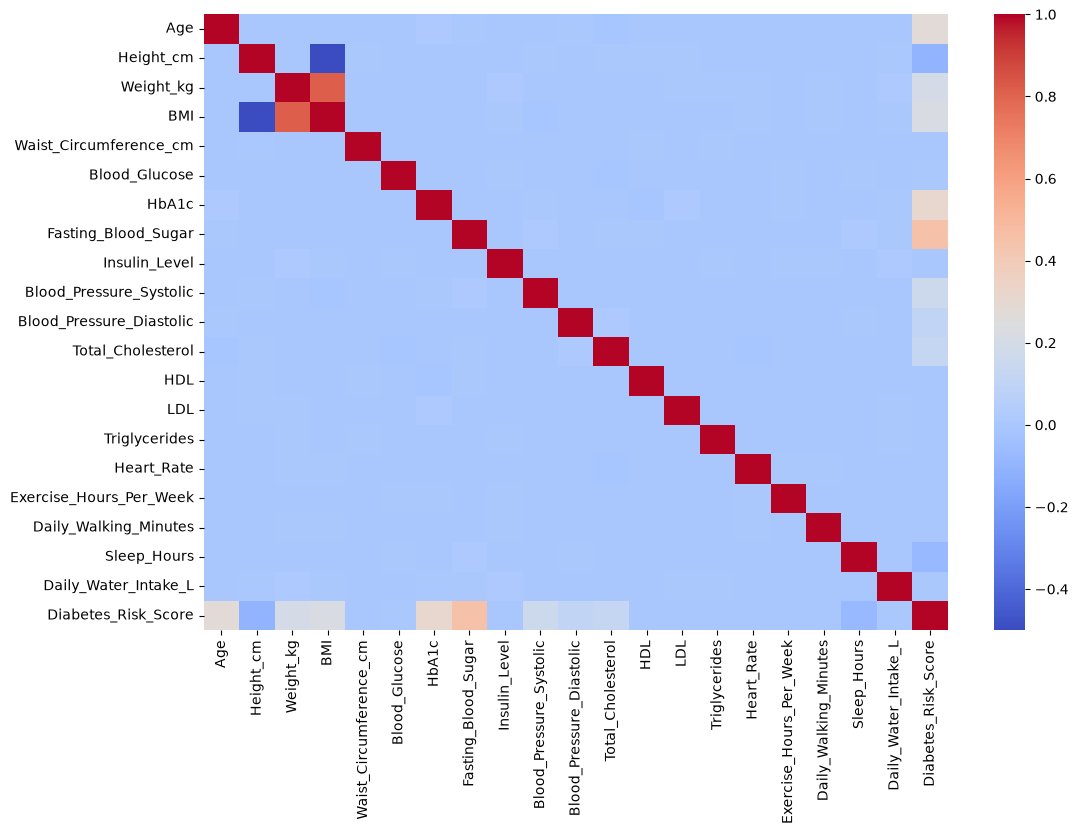

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.show()

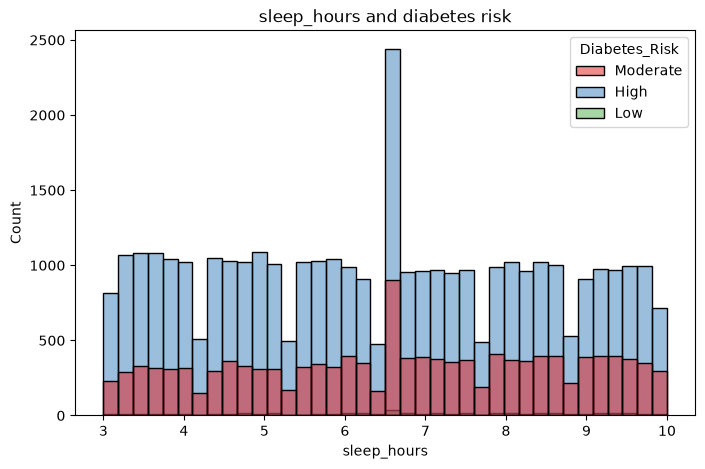

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(data= df,x= 'Sleep_Hours',hue= 'Diabetes_Risk',palette= 'Set1')
plt.title('sleep_hours and diabetes risk')
plt.xlabel('sleep_hours')
plt.show()

In [37]:
from sklearn.cluster import KMeans
kmeans = KMeans( n_clusters = 6 )

In [58]:
p = df['Diabetes_Risk']
x =  df.select_dtypes(include=['float64', 'int64']).columns
s = df[['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score']]
s.head()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
0,32.0,182.1,65.8,19.8,71.2,88.4,10.4,149.5,27.4,94,...,138.7,40.1,152.3,250.8,119,2.2,106.1,7.9,4.4,60
1,42.0,148.5,101.2,45.9,121.8,247.3,11.3,199.3,18.3,148,...,286.8,35.6,110.4,287.9,59,6.3,96.1,6.2,2.1,99
2,89.0,158.1,87.3,37.9,131.8,141.9,6.3,219.6,23.9,101,...,129.4,32.1,156.7,329.3,104,0.6,68.7,4.8,2.8,80
3,87.0,190.9,95.9,26.3,99.1,90.1,7.4,217.7,36.7,120,...,168.2,61.9,63.4,308.8,58,7.7,23.1,4.2,1.5,82
4,27.0,156.9,101.9,41.4,77.1,93.8,12.0,153.5,22.3,190,...,281.5,37.4,66.5,206.6,104,4.7,131.2,9.9,1.6,93


In [73]:
label = labels = kmeans.fit_predict(s)
df['cluster'] = label
df.head(1)

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,Doctor_Consultation_Needed,Diabetes_Risk,cluster
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Yes,No,Good,Retired,Rural,4.4,60,Yes,Moderate,5


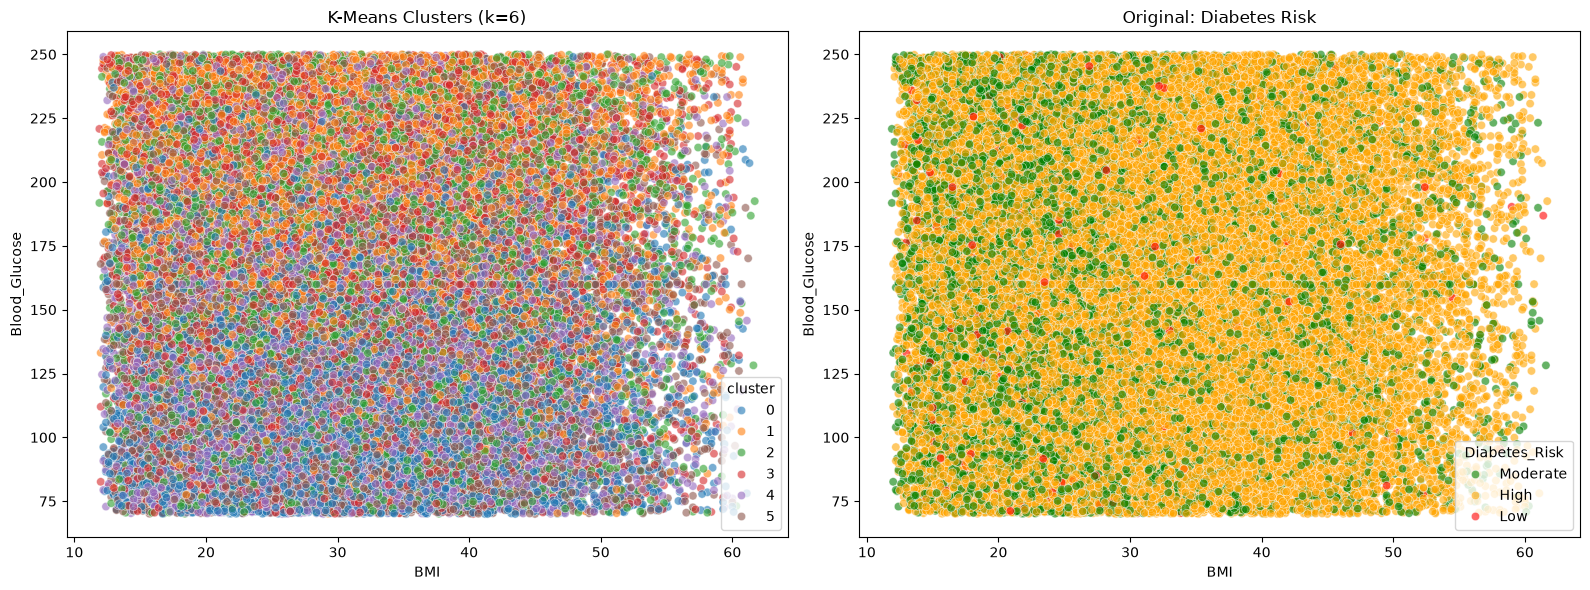

In [75]:
# 2. Side-by-side plot: Ek taraf K-Means Clusters, doosri taraf Original Diabetes Risk
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Clusters Plot (yahan 'cluster' small letters mein rakhein)
sns.scatterplot(
    data=df, 
    x='BMI', 
    y='Blood_Glucose', 
    hue='cluster', 
    palette='tab10', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('K-Means Clusters (k=6)')

# Original Diabetes Risk Plot
sns.scatterplot(
    data=df, 
    x='BMI', 
    y='Blood_Glucose', 
    hue='Diabetes_Risk', 
    palette=['green', 'orange', 'red'], 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Original: Diabetes Risk')

plt.tight_layout()
plt.show()

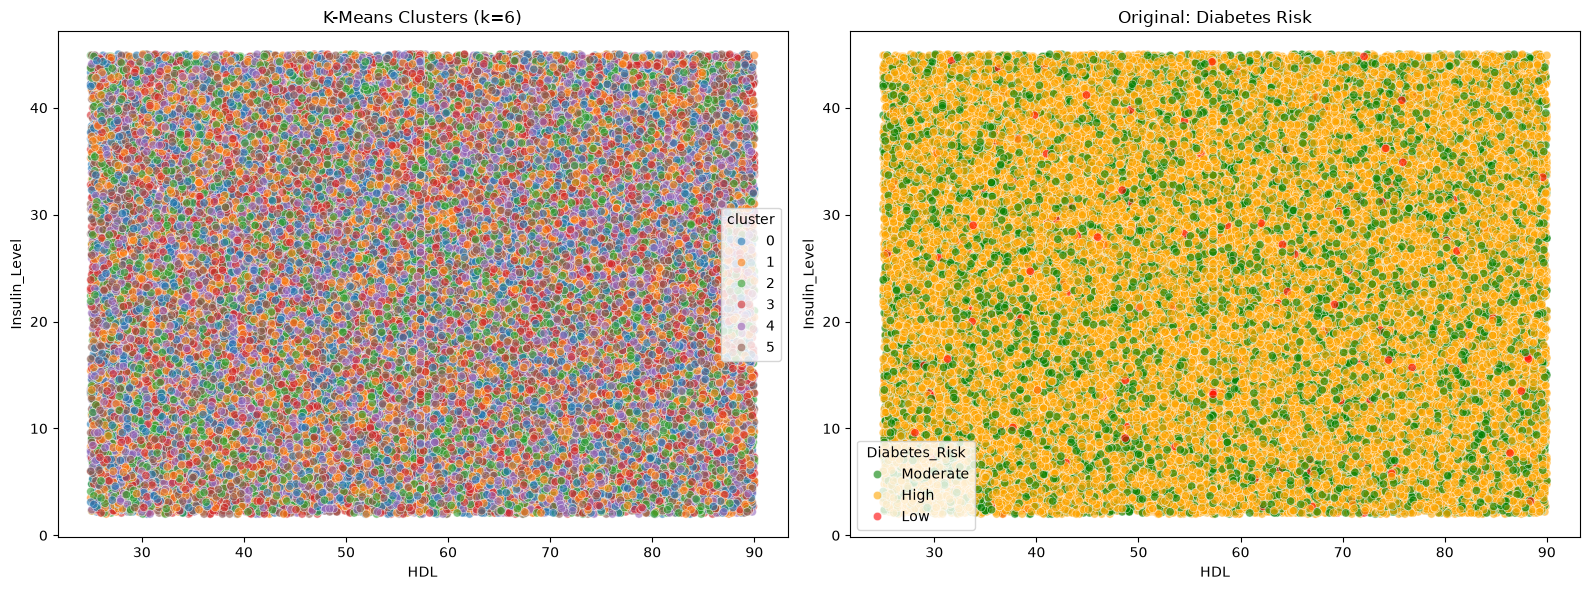

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Clusters Plot (yahan 'cluster' small letters mein rakhein)
sns.scatterplot(
    data=df, 
    x='HDL', 
    y='Insulin_Level', 
    hue='cluster', 
    palette='tab10', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('K-Means Clusters (k=6)')

# Original Diabetes Risk Plot
sns.scatterplot(
    data=df, 
    x='HDL', 
    y='Insulin_Level', 
    hue='Diabetes_Risk', 
    palette=['green', 'orange', 'red'], 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Original: Diabetes Risk')

plt.tight_layout()
plt.show()

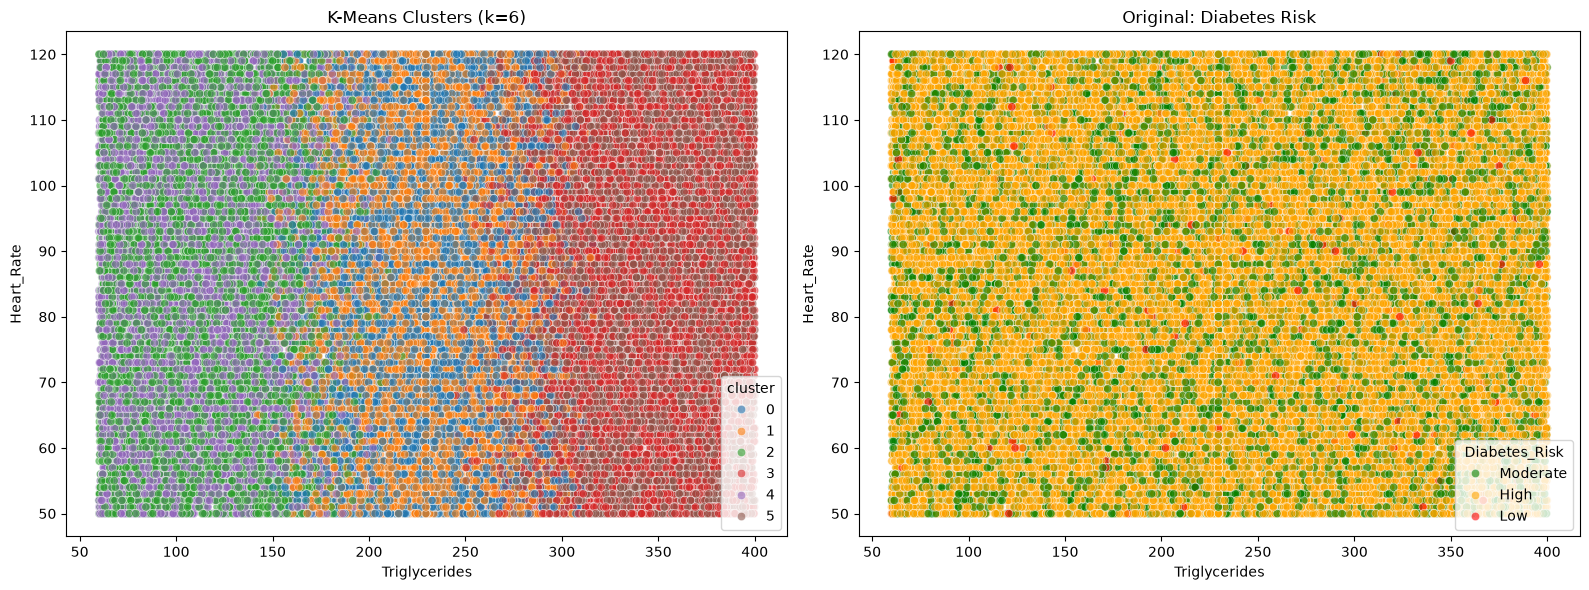

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Clusters Plot (yahan 'cluster' small letters mein rakhein)
sns.scatterplot(
    data=df, 
    x='Triglycerides', 
    y='Heart_Rate', 
    hue='cluster', 
    palette='tab10', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('K-Means Clusters (k=6)')

# Original Diabetes Risk Plot
sns.scatterplot(
    data=df, 
    x='Triglycerides', 
    y='Heart_Rate', 
    hue='Diabetes_Risk', 
    palette=['green', 'orange', 'red'], 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Original: Diabetes Risk')

plt.tight_layout()
plt.show()